In [28]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


from PIL import Image

In [29]:
with open('imagenet_classes.txt') as f:
    class_names = [line.strip() for line in f.readlines()]

In [30]:
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [31]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

torch.Size([1, 3, 224, 224])


Text(0.5, 1.0, 'predicted class: African crocodile\nwith confidence: 97.77%')

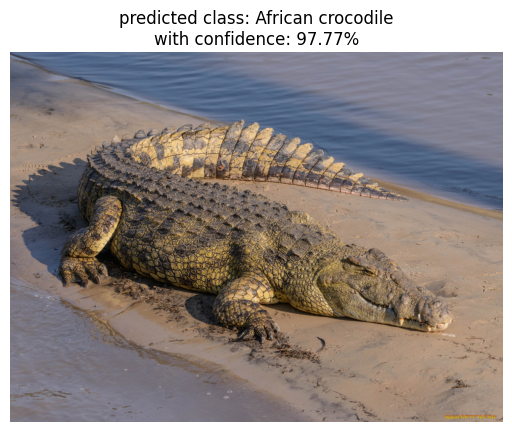

In [40]:
import numpy as np

i = np.random.randint(1, 5)

image_path = f'images/{i}.jpg'
image = Image.open(image_path)
image_tensor = preprocess(image).unsqueeze(0)
print(image_tensor.shape)
image_tensor = image_tensor.to(device)

with torch.no_grad():
    output = model(image_tensor)

probs = torch.nn.functional.softmax(output[0], dim=0).cpu()
class_names[probs.argmax()]

top_prob, top_class = torch.topk(probs, 1)
confidence = top_prob.item()
top_class = top_class.item()

class_name = class_names[top_class]

plt.imshow(image)
plt.axis('off')
plt.title(f"predicted class: {class_name}\n"
          f"with confidence: {confidence*100:.2f}%")

# ONNX

In [10]:
dummy_input = torch.randn(1, 3, 224, 224, device=device)
onnx_file_path = "model.onnx"

with torch.no_grad():
    torch.onnx.export(
        model,
        dummy_input,
        onnx_file_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        external_data=False,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )

/tmp/ipykernel_3188848/1578757306.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0618 20:29:43.489000 3188848 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0618 20:29:43.490000 3188848 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0618 20:29:43.490000 3188848 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input,

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/home/mordrud/.local/share/mise/installs/python/3.11.15/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


In [11]:
import onnx

onnx_model = onnx.load('model.onnx')
try:
    onnx.checker.check_model(onnx_model)
    print("👍️")
except onnx.checker.ValidationError as e:
    print(f"👎️ Error message: {e}")

👍️


# Softmax

In [12]:
import torch.nn as nn

model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

model = nn.Sequential(
    model,
    nn.Softmax(dim=1)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

Sequential(
  (0): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0)

In [13]:
dummy_input = torch.randn(1, 3, 224, 224, device=device)
onnx_file_path = "model.onnx"

with torch.no_grad():
    torch.onnx.export(
        model,
        dummy_input,
        onnx_file_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        external_data=False,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )

onnx_model = onnx.load('model.onnx')
try:
    onnx.checker.check_model(onnx_model)
    print("👍️")
except onnx.checker.ValidationError as e:
    print(f"👎️ Error message: {e}")

/tmp/ipykernel_3188848/1186867757.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0619 00:54:17.780000 3188848 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0619 00:54:17.781000 3188848 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0619 00:54:17.781000 3188848 site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input,

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/home/mordrud/.local/share/mise/installs/python/3.11.15/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
👍️
